# Quality control of the Norman Perturb-seq subset

This notebook continues from `01_explore_dataset.ipynb`. It loads the cached working subset containing negative controls and five well-represented single-gene perturbations, then evaluates expression-level and guide-assignment quality.

Run notebook 01 first whenever the cached subset is missing or the upstream perturbation selection changes.

In [7]:
from pathlib import Path

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the cached subset

The path logic supports launching Jupyter from either the repository root or the `notebooks/` directory. Loading the selected subset avoids reading the complete 111,255-cell dataset for every downstream analysis session.

In [8]:
current_directory = Path.cwd().resolve()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)
subset_path = project_root / "data" / "norman_2019_selected.h5ad"

if not subset_path.exists():
    raise FileNotFoundError(
        f"Cached subset not found at {subset_path}. "
        "Run notebooks/01_explore_dataset.ipynb first."
    )

adata_sub = sc.read_h5ad(subset_path)
selected_perturbations = ["KLF1", "BAK1", "CEBPE", "ETS2", "MAP2K6"]

print(adata_sub)
adata_sub.obs["perturbation_name"].value_counts()

AnnData object with n_obs × n_vars = 18549 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', 'g

perturbation_name
control    11835
KLF1        1954
BAK1        1451
CEBPE       1230
ETS2        1201
MAP2K6       878
Name: count, dtype: int64

## Quality control of the working subset

Quality control (QC) asks whether technical properties of the cells or guide assignments could distort the biological comparisons. Here, QC is performed on the control cells and the five selected single-gene perturbations.

This `AnnData` object is **already processed**: it contains highly-variable-gene annotations, PCA coordinates, a neighbor graph, UMAP coordinates, and Leiden clusters. It is therefore not equivalent to a raw count matrix produced directly from FASTQ files. The original count-scale expression values are retained in `adata_sub.layers["counts"]`; later count-based models should use that layer explicitly.

The goals of this section are to:

1. confirm which expression and guide-QC fields are available;
2. compare QC distributions across perturbations, rather than applying a single threshold blindly;
3. inspect the consequences of candidate filters before excluding cells; and
4. retain an auditable record of every QC decision.

A perturbation may genuinely alter RNA content, mitochondrial expression, or cell state. Consequently, an apparent QC outlier can be biological rather than technical. This section creates diagnostic flags but does not filter `adata_sub` automatically.

In [9]:
expression_qc_metrics = [
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt",
]
guide_qc_metrics = [
    "read_count",
    "UMI_count",
    "coverage",
    "good_coverage",
    "number_of_cells",
]
required_metrics = expression_qc_metrics + guide_qc_metrics
missing_metrics = [
    metric for metric in required_metrics
    if metric not in adata_sub.obs.columns
]

assert not missing_metrics, f"Missing expected QC fields: {missing_metrics}"
assert "counts" in adata_sub.layers, "Raw counts layer is unavailable"

print("Cells in working subset:", adata_sub.n_obs)
print("Genes in working subset:", adata_sub.n_vars)
print("Expression matrix type:", type(adata_sub.X).__name__)
print("Available layers:", list(adata_sub.layers.keys()))
print("Precomputed embeddings:", list(adata_sub.obsm.keys()))

Cells in working subset: 18549
Genes in working subset: 19018
Expression matrix type: csr_matrix
Available layers: ['counts']
Precomputed embeddings: ['X_pca', 'X_umap']


### Expression-level QC

Three common cell-level metrics provide complementary information:

- `n_genes_by_counts` is the number of detected genes. Very small values can indicate low-complexity libraries, while unusually large values can be associated with multiplets or unusually RNA-rich cells.
- `total_counts` is the total number of captured transcript counts. It measures library size, but it can also change for biological reasons.
- `pct_counts_mt` is the percentage of counts assigned to mitochondrial genes. High values can indicate stressed or damaged cells, although the appropriate cutoff is dataset- and cell-state-dependent.

The tables below report both overall quantiles and perturbation-specific medians. Group-wise summaries matter because a threshold that disproportionately removes one perturbation can create or erase an apparent perturbation effect.

In [10]:
quantiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]

expression_qc_summary = (
    adata_sub.obs[expression_qc_metrics]
    .describe(percentiles=quantiles)
    .T
)
expression_qc_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
n_genes_by_counts,18549.0,3441.368376,702.354290,974.000000,1689.000000,2179.400000,3027.000000,3432.000000,3886.000000,4606.000000,5117.000000,5965.000000
total_counts,18549.0,16164.404297,5937.823730,3870.000000,4749.480000,6999.000000,12291.000000,15394.000000,19531.000000,26952.000000,33218.920000,51649.000000
pct_counts_mt,18549.0,6.293187,1.369599,0.113688,3.246616,4.270224,5.394826,6.201172,7.105167,8.573532,10.016798,14.813339


In [11]:
grouped_expression_qc = (
    adata_sub.obs
    .groupby("perturbation_name", observed=True)[expression_qc_metrics]
    .agg(["count", "median", "mean"])
)
grouped_expression_qc

n_genes_by_counts                      total_counts  \
                              count  median         mean        count   
perturbation_name                                                       
BAK1                           1451  3464.0  3494.134390         1451   
CEBPE                          1230  3026.5  3009.254472         1230   
ETS2                           1201  3221.0  3272.028310         1201   
KLF1                           1954  3571.5  3581.725691         1954   
MAP2K6                          878  3644.5  3623.234624          878   
control                       11835  3443.0  3460.327165        11835   

                                         pct_counts_mt                      
                    median          mean         count    median      mean  
perturbation_name                                                           
BAK1               15945.0  16767.562500          1451  6.114329  6.190445  
CEBPE              12097.5  12708.798828          1230  6.840746  6.878475  
ETS2               13549.0  14395.968750          1201  5.939489  6.020130  
KLF1               17013.0  17650.494141          1954  6.057349  6.140684  
MAP2K6             17617.0  18281.955078           878  5.778307  5.846647  
control            15432.0  16226.598633         11835  6.237410  6.330970

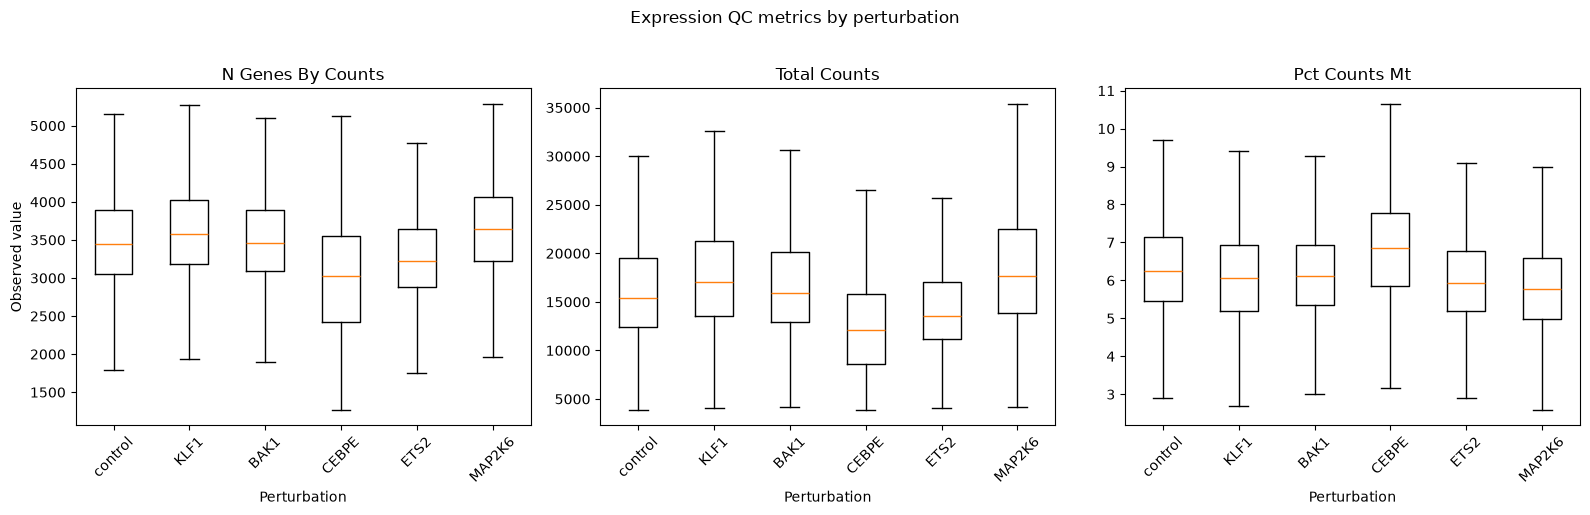

In [12]:
plot_order = ["control"] + selected_perturbations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, expression_qc_metrics):
    plot_data = [
        adata_sub.obs.loc[
            adata_sub.obs["perturbation_name"] == perturbation, metric
        ].dropna()
        for perturbation in plot_order
    ]
    ax.boxplot(plot_data, showfliers=False)
    ax.set_xticks(range(1, len(plot_order) + 1), plot_order)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Perturbation")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Observed value")
fig.suptitle("Expression QC metrics by perturbation", y=1.02)
plt.tight_layout()
plt.show()

### Guide-assignment QC

Perturb-seq analysis also depends on confidence in the mapping from cells to perturbations. The Norman dataset provides several relevant fields:

- `read_count` and `UMI_count` summarize sequencing support for the guide assignment;
- `coverage` relates read support to guide UMIs;
- `good_coverage` is the dataset provider's existing coverage-quality annotation; and
- `number_of_cells` is a provider-supplied assignment metadata field. Its distribution is inspected rather than assuming that its name alone defines singlets or multiplets.

These fields concern guide assignment and should not be confused with gene-expression library size. The provider's `good_coverage` annotation is useful, but it is still important to check whether it behaves differently across perturbation groups.

In [13]:
guide_qc_summary = (
    adata_sub.obs[["read_count", "UMI_count", "coverage"]]
    .describe(percentiles=quantiles)
    .T
)
guide_qc_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
read_count,18549.0,1235.232573,826.242950,1.0,2.0,39.000000,651.000000,1151.000000,1672.000000,2689.200000,3747.560000,11288.0
UMI_count,18549.0,58.364925,35.600739,1.0,1.0,2.000000,33.000000,57.000000,79.000000,119.000000,155.000000,513.0
coverage,18549.0,20.599782,6.606620,1.0,2.0,12.148606,17.411765,20.025641,23.019231,33.435452,38.728758,74.0


In [14]:
assignment_metadata_counts = (
    adata_sub.obs["number_of_cells"]
    .value_counts(dropna=False)
    .sort_index()
)
assignment_metadata_counts

number_of_cells
0     1083
1    15209
2     2028
3      210
4       17
5        2
Name: count, dtype: int64

In [15]:
guide_qc_by_perturbation = (
    adata_sub.obs
    .groupby("perturbation_name", observed=True)
    .agg(
        n_cells=("perturbation_name", "size"),
        good_coverage_fraction=("good_coverage", "mean"),
        median_guide_reads=("read_count", "median"),
        median_guide_umis=("UMI_count", "median"),
        median_coverage=("coverage", "median"),
    )
    .reindex(plot_order)
)
guide_qc_by_perturbation

,n_cells,good_coverage_fraction,median_guide_reads,median_guide_umis,median_coverage
perturbation_name,,,,,
control,11835,0.943388,1199.0,58.0,20.234043
KLF1,1954,0.940123,987.5,54.0,18.069919
BAK1,1451,0.925569,1163.0,55.0,20.816327
CEBPE,1230,0.950407,1055.0,49.0,21.612380
ETS2,1201,0.937552,1061.0,53.0,19.571429
MAP2K6,878,0.940774,1200.0,60.0,19.339685


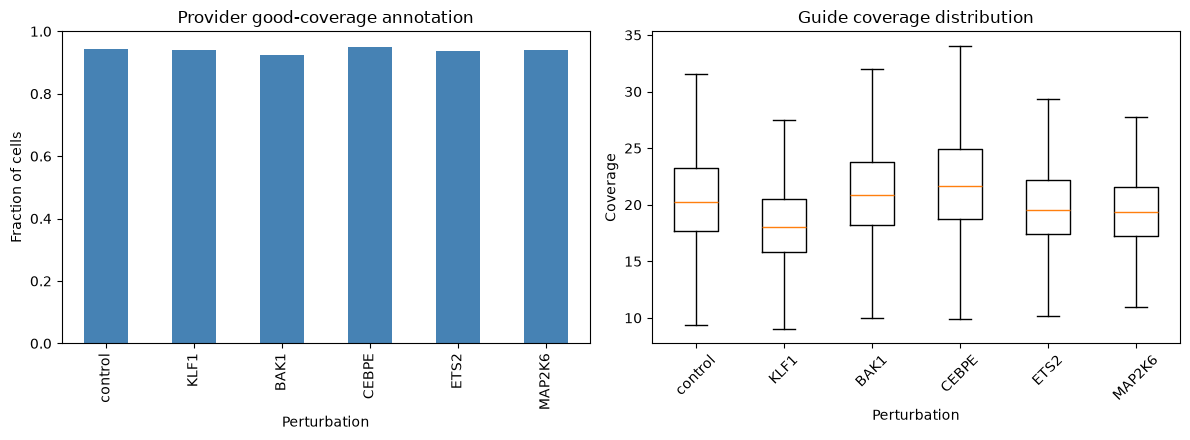

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

guide_qc_by_perturbation["good_coverage_fraction"].plot.bar(
    ax=axes[0], color="steelblue"
)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Fraction of cells")
axes[0].set_xlabel("Perturbation")
axes[0].set_title("Provider good-coverage annotation")

coverage_data = [
    adata_sub.obs.loc[
        adata_sub.obs["perturbation_name"] == perturbation, "coverage"
    ].dropna()
    for perturbation in plot_order
]
axes[1].boxplot(coverage_data, showfliers=False)
axes[1].set_xticks(range(1, len(plot_order) + 1), plot_order)
axes[1].set_ylabel("Coverage")
axes[1].set_xlabel("Perturbation")
axes[1].set_title("Guide coverage distribution")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Candidate QC flags and sensitivity analysis

The following flags are deliberately transparent and conservative. The 1st and 99th percentiles identify extreme library-size or complexity observations relative to this working subset; `pct_counts_mt > 20` is included as a conventional diagnostic threshold; and `~good_coverage` identifies cells that fail the provider's guide-coverage annotation.

These are **candidate exclusion criteria, not universal biological truths**. In particular, empirical quantiles guarantee that some cells are flagged even when no technical failure occurred. Before filtering, we compare retention across perturbations under several scenarios. A large group-specific loss would require closer investigation and a sensitivity analysis in downstream results.

In [17]:
gene_lower, gene_upper = adata_sub.obs["n_genes_by_counts"].quantile([0.01, 0.99])
count_lower, count_upper = adata_sub.obs["total_counts"].quantile([0.01, 0.99])

qc_flags = pd.DataFrame(index=adata_sub.obs_names)
qc_flags["extreme_gene_count"] = ~adata_sub.obs["n_genes_by_counts"].between(
    gene_lower, gene_upper
)
qc_flags["extreme_total_counts"] = ~adata_sub.obs["total_counts"].between(
    count_lower, count_upper
)
qc_flags["high_mitochondrial_fraction"] = adata_sub.obs["pct_counts_mt"] > 20
qc_flags["poor_guide_coverage"] = ~adata_sub.obs["good_coverage"].astype(bool)

pd.DataFrame(
    {
        "flagged_cells": qc_flags.sum(),
        "flagged_fraction": qc_flags.mean(),
    }
).sort_values("flagged_fraction", ascending=False)

,flagged_cells,flagged_fraction
poor_guide_coverage,1083,0.058386
extreme_total_counts,372,0.020055
extreme_gene_count,369,0.019893
high_mitochondrial_fraction,0,0.000000


In [18]:
qc_scenarios = pd.DataFrame(
    {
        "all_cells": True,
        "expression_qc": ~(
            qc_flags["extreme_gene_count"]
            | qc_flags["extreme_total_counts"]
            | qc_flags["high_mitochondrial_fraction"]
        ),
        "guide_qc": ~qc_flags["poor_guide_coverage"],
        "expression_and_guide_qc": ~qc_flags.any(axis=1),
    },
    index=adata_sub.obs_names,
)

retention_by_perturbation = (
    qc_scenarios
    .assign(perturbation_name=adata_sub.obs["perturbation_name"].values)
    .groupby("perturbation_name", observed=True)
    .mean()
    .reindex(plot_order)
)
retention_by_perturbation

,all_cells,expression_qc,guide_qc,expression_and_guide_qc
perturbation_name,,,,
control,1.0,0.977271,0.943388,0.922180
KLF1,1.0,0.971853,0.940123,0.913511
BAK1,1.0,0.979325,0.925569,0.906272
CEBPE,1.0,0.939837,0.950407,0.891870
ETS2,1.0,0.983347,0.937552,0.920899
MAP2K6,1.0,0.966970,0.940774,0.908884


### QC decision checkpoint

Before creating a filtered object, inspect all tables and figures above and record the answers to these questions:

1. Are any expression-QC distributions clearly bimodal or dominated by extreme tails?
2. Does any perturbation have systematically different RNA content or mitochondrial percentage?
3. Does the provider's `good_coverage` flag remove a similar fraction from every group?
4. Are the conclusions robust when flagged cells are retained versus excluded?

No cells are removed at this stage. After examining the executed outputs, the chosen criteria should be stated here in plain language, along with the number and percentage of cells removed from each perturbation. Downstream analyses should ideally be repeated with and without borderline cells if the conclusions are sensitive to the QC definition.